# TemporalVAE training on hEmbryo 8 datasets and predicting on David dataset.

In [2]:
import os
os.getcwd()

'/home/yiming/TemporalVAE/examples'

In [22]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
os.chdir("/home/yiming/TemporalVAE/")
import sys
sys.path.append(os.getcwd())


In [23]:
from TemporalVAE import datasets

adata_hEmbryo8 = datasets.hEmbryo8(show_datadir=True)
adata_hEmbryo8

data/rawCount_Z_C_Xiao_M_P_Liu_Tyser_Xiang.filtered.h5ad


AnnData object with n_obs × n_vars = 25003 × 1692
    obs: 'time', 'day', 'dataset_label', 'donor', 'cell_type', 'title', 'species', 'n_genes', 'tvae_predicted_time'
    var: 'n_cells'
    obsm: 'X_umap', 'tvae_emb'
    layers: 'processed'

## Import necessary packages and function

In [24]:
from TemporalVAE.utils.utils_project import *
from TemporalVAE.utils.utils_project import *
from collections import Counter
import os
import yaml
import argparse
import anndata as ad
import numpy as np
import pandas as pd
import logging
from TemporalVAE.utils import LogHelper
import torch

### Set necessary parameters for dataset preprocessing and model training

In [131]:
result_save_path="results//test/TemporalVAE_human_ref6dataset_queryOnDavid/"
data_golbal_path = "/home/yiming/TemporalVAE/"
data_path="examples/reference_plus_mydata.h5ad"
min_gene_num=50
min_cell_num=50
train_epoch_num=50
batch_size=100000
time_standard_type="embryoneg5to5"
vae_param_file="supervise_vae_regressionclfdecoder_mouse_stereo"
os.getcwd()
vae_param_file

'supervise_vae_regressionclfdecoder_mouse_stereo'

### import vae model parameters from yaml file

In [132]:
with open(f"vae_model_configs/{vae_param_file}.yaml", 'r') as file:
    try:
        config = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)

### set logger and parameters, creat result save path and folder

In [133]:
latent_dim = config['model_params']['latent_dim']
_path = '{}/{}/'.format(result_save_path, "/human_embryo_preimplantation/integration_8dataset/")
if not os.path.exists(_path):
    os.makedirs(_path)
_path

'results//test/TemporalVAE_human_ref6dataset_queryOnDavid///human_embryo_preimplantation/integration_8dataset//'

In [134]:
logger_file = '{}/{}_dim{}_time{}_epoch{}_minGeneNum{}.log'.format(_path, vae_param_file, latent_dim,
                                                                   time_standard_type, train_epoch_num,
                                                                   min_gene_num)
LogHelper.setup(log_path=logger_file, level='INFO')
_logger = logging.getLogger(__name__)
_logger.info("Finished setting up the logger at: {}.".format(logger_file))
_logger.info("Train on dataset: {}.".format(data_path))

_logger.info("load vae model parameters from file: {}".format(vae_param_file + ".yaml"))

2026-03-16 02:56:13,784 INFO - __main__ - Finished setting up the logger at: results//test/TemporalVAE_human_ref6dataset_queryOnDavid///human_embryo_preimplantation/integration_8dataset///supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50.log. 
2026-03-16 02:56:13,784 INFO - __main__ - Finished setting up the logger at: results//test/TemporalVAE_human_ref6dataset_queryOnDavid///human_embryo_preimplantation/integration_8dataset///supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50.log. 
2026-03-16 02:56:13,784 INFO - __main__ - Finished setting up the logger at: results//test/TemporalVAE_human_ref6dataset_queryOnDavid///human_embryo_preimplantation/integration_8dataset///supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50.log. 
2026-03-16 02:56:13,784 INFO - __main__ - Finished setting up the logger at: results//test/TemporalVAE_human_ref6dataset_queryOnDavid///hum

In [135]:
sc_expression_df, cell_time, adata_filtered = preprocessData_and_dropout_some_donor_or_gene(data_golbal_path,
                                                                                data_path,
                                                                                cell_info_file=None,
                                                                                # donor_attr=donor_attr,
                                                                                # drop_out_donor=drop_out_donor,
                                                                                # external_file_name=query_data_file_csv,
                                                                                # external_cell_info_file=query_cell_info_file_csv,
                                                                                min_cell_num=min_cell_num,
                                                                                min_gene_num=min_gene_num,
                                                                                data_raw_count_bool=True,
                                                                                return_normalized_raw_count=True)

2026-03-16 02:56:16,077 INFO - TemporalVAE.utils.utils_project - the original sc expression anndata should be gene as row, cell as column 
2026-03-16 02:56:16,077 INFO - TemporalVAE.utils.utils_project - the original sc expression anndata should be gene as row, cell as column 
2026-03-16 02:56:16,077 INFO - TemporalVAE.utils.utils_project - the original sc expression anndata should be gene as row, cell as column 
2026-03-16 02:56:16,077 INFO - TemporalVAE.utils.utils_project - the original sc expression anndata should be gene as row, cell as column 
2026-03-16 02:56:16,079 INFO - TemporalVAE.utils.utils_project - input data is .h5 or .h5ad file, where cell as column and gene as row. 
2026-03-16 02:56:16,079 INFO - TemporalVAE.utils.utils_project - input data is .h5 or .h5ad file, where cell as column and gene as row. 
2026-03-16 02:56:16,079 INFO - TemporalVAE.utils.utils_project - input data is .h5 or .h5ad file, where cell as column and gene as row. 
2026-03-16 02:56:16,079 INFO - Te

normalized sample to 1000000.0


2026-03-16 02:56:18,505 INFO - TemporalVAE.utils.utils_project - Finish normalize per cell to 1000000.0, so that every cell has the same total count after normalization. 
2026-03-16 02:56:18,505 INFO - TemporalVAE.utils.utils_project - Finish normalize per cell to 1000000.0, so that every cell has the same total count after normalization. 
2026-03-16 02:56:18,505 INFO - TemporalVAE.utils.utils_project - Finish normalize per cell to 1000000.0, so that every cell has the same total count after normalization. 
2026-03-16 02:56:18,505 INFO - TemporalVAE.utils.utils_project - Finish normalize per cell to 1000000.0, so that every cell has the same total count after normalization. 


Input data is raw count, do the log1p().


2026-03-16 02:56:22,723 INFO - TemporalVAE.utils.utils_project - Finish normalize per gene as Gaussian-dist (0, 1). 
2026-03-16 02:56:22,723 INFO - TemporalVAE.utils.utils_project - Finish normalize per gene as Gaussian-dist (0, 1). 
2026-03-16 02:56:22,723 INFO - TemporalVAE.utils.utils_project - Finish normalize per gene as Gaussian-dist (0, 1). 
2026-03-16 02:56:22,723 INFO - TemporalVAE.utils.utils_project - Finish normalize per gene as Gaussian-dist (0, 1). 
2026-03-16 02:56:22,856 INFO - TemporalVAE.utils.utils_project - Get expression dataframe with shape (cell, gene): (72604, 1550), and cell time info with shape: (72604, 6). 
2026-03-16 02:56:22,856 INFO - TemporalVAE.utils.utils_project - Get expression dataframe with shape (cell, gene): (72604, 1550), and cell time info with shape: (72604, 6). 
2026-03-16 02:56:22,856 INFO - TemporalVAE.utils.utils_project - Get expression dataframe with shape (cell, gene): (72604, 1550), and cell time info with shape: (72604, 6). 
2026-03-16

In [136]:
sc_expression_df

,A1CF,A2M,AADAT,AAMDC,ABAT,ABCA6,ABCA9,ABCC11,ABCC12,ABCC3,...,ZNF750,ZNF831,ZNF835,ZNF836,ZNF853,ZP3,ZSCAN10,ZSCAN4,ZSCAN5B,ZSWIM6
CS7_315,-0.146474,-0.262701,-0.441461,-0.886317,-0.326368,-0.058427,-0.08755,-0.077195,-0.081381,-0.201025,...,-0.362452,-0.036987,-0.160156,-0.376792,-0.190022,-0.284923,-0.604458,-0.136214,-0.079795,-0.914239
CS7_317,-0.146474,-0.262701,-0.441461,-0.886317,-0.326368,-0.058427,-0.08755,-0.077195,-0.081381,-0.201025,...,3.360158,-0.036987,-0.160156,-0.376792,-0.190022,-0.284923,1.511121,-0.136214,-0.079795,-0.914239
CS7_318,-0.146474,-0.262701,-0.441461,-0.886317,-0.326368,-0.058427,-0.08755,-0.077195,-0.081381,-0.201025,...,-0.362452,-0.036987,-0.160156,-0.376792,-0.190022,-0.284923,-0.604458,-0.136214,-0.079795,-0.914239
CS7_320,-0.146474,-0.262701,-0.441461,-0.886317,-0.326368,-0.058427,-0.08755,-0.077195,-0.081381,-0.201025,...,-0.362452,-0.036987,-0.160156,-0.376792,-0.190022,-0.284923,-0.604458,-0.136214,-0.079795,-0.914239
CS7_324,-0.146474,-0.262701,-0.441461,-0.886317,-0.326368,-0.058427,-0.08755,-0.077195,-0.081381,-0.201025,...,-0.362452,-0.036987,-0.160156,-0.376792,-0.190022,-0.284923,-0.604458,-0.136214,-0.079795,-0.914239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTACGTTGGGCCT-1-KO_d9,-0.146474,-0.262701,-0.441461,-0.886317,-0.326368,-0.058427,-0.08755,-0.077195,-0.081381,-0.201025,...,-0.362452,-0.036987,-0.160156,-0.376792,-0.190022,-0.284923,-0.604458,-0.136214,-0.079795,1.061255
TGTGTACGTTGTCTGG-1-KO_d9,-0.146474,-0.262701,-0.441461,-0.886317,-0.326368,-0.058427,-0.08755,-0.077195,-0.081381,-0.201025,...,-0.362452,-0.036987,-0.160156,-0.376792,-0.190022,-0.284923,1.821085,-0.136214,-0.079795,-0.914239
TGTGTACGTTGTGGTT-1-KO_d9,-0.146474,-0.262701,-0.441461,-0.886317,-0.326368,-0.058427,-0.08755,-0.077195,-0.081381,-0.201025,...,-0.362452,-0.036987,-0.160156,-0.376792,-0.190022,-0.284923,-0.604458,-0.136214,-0.079795,-0.914239
TGTGTTAGTTCCCAGA-1-KO_d9,-0.146474,-0.262701,-0.441461,1.122368,-0.326368,-0.058427,-0.08755,-0.077195,-0.081381,-0.201025,...,-0.362452,-0.036987,-0.160156,-0.376792,-0.190022,-0.284923,-0.604458,-0.136214,-0.079795,-0.914239


In [137]:
cell_time

,time,day,dataset_label,donor,cell_type,n_genes
CS7_315,17.5,D17.5_cui,C,D17.5_cui,Connecting stalk,216
CS7_317,17.5,D17.5_cui,C,D17.5_cui,Connecting stalk,238
CS7_318,17.5,D17.5_cui,C,D17.5_cui,Connecting stalk,219
CS7_320,17.5,D17.5_cui,C,D17.5_cui,Connecting stalk,227
CS7_324,17.5,D17.5_cui,C,D17.5_cui,Connecting stalk,199
...,...,...,...,...,...,...
TGTGTACGTTGGGCCT-1-KO_d9,9.0,KO_d9,MyData,KO_d9,Amnion,266
TGTGTACGTTGTCTGG-1-KO_d9,9.0,KO_d9,MyData,KO_d9,TB,213
TGTGTACGTTGTGGTT-1-KO_d9,9.0,KO_d9,MyData,KO_d9,TB,211
TGTGTTAGTTCCCAGA-1-KO_d9,9.0,KO_d9,MyData,KO_d9,Cardiac Mesoderm,323


### Set donor list and dictionary

In [138]:
donor_list = np.unique(cell_time["dataset_label"])
donor_list = sorted(donor_list, key=Embryodonor_resort_key)
donor_dic = dict()
for i in range(len(donor_list)):
    donor_dic[donor_list[i]] = i
batch_dic = donor_dic.copy()
_logger.info("Consider donor as batch effect, donor use label: {}".format(donor_dic))
_logger.info("For each donor (donor_id, cell_num):{} ".format(Counter(cell_time["time"])))
save_path = f"{_logger.root.handlers[0].baseFilename.replace('.log', '')}/"

2026-03-16 02:56:33,594 INFO - __main__ - Consider donor as batch effect, donor use label: {'C': 0, 'L': 1, 'M': 2, 'MyData': 3, 'P': 4, 'T': 5, 'Xiang': 6, 'Xiao': 7, 'Z': 8} 
2026-03-16 02:56:33,594 INFO - __main__ - Consider donor as batch effect, donor use label: {'C': 0, 'L': 1, 'M': 2, 'MyData': 3, 'P': 4, 'T': 5, 'Xiang': 6, 'Xiao': 7, 'Z': 8} 
2026-03-16 02:56:33,594 INFO - __main__ - Consider donor as batch effect, donor use label: {'C': 0, 'L': 1, 'M': 2, 'MyData': 3, 'P': 4, 'T': 5, 'Xiang': 6, 'Xiao': 7, 'Z': 8} 
2026-03-16 02:56:33,594 INFO - __main__ - Consider donor as batch effect, donor use label: {'C': 0, 'L': 1, 'M': 2, 'MyData': 3, 'P': 4, 'T': 5, 'Xiang': 6, 'Xiao': 7, 'Z': 8} 
2026-03-16 02:56:33,607 INFO - __main__ - For each donor (donor_id, cell_num):Counter({6.0: 26662, 9.0: 25406, 17.5: 6277, 18.5: 4938, 8.0: 2136, 10.0: 1787, 11.0: 1616, 12.0: 942, 14.0: 672, 7.0: 531, 6.5: 529, 5.0: 377, 7.5: 355, 4.0: 190, 5.5: 105, 3.0: 81})  
2026-03-16 02:56:33,607 INFO

## TASK: use 8 hEmbryo datasets as reference data to train a model, then predict on David dataset.

### 1. remove David from  8 hEmbryo dataset.

In [139]:
drop_out_donor = ["MyData", "T", "Xiang"]  #
print(f"drop the donor: {drop_out_donor}")
cell_drop_index_list = cell_time.loc[cell_time["dataset_label"].isin(drop_out_donor)].index
sc_expression_df_filter = sc_expression_df.drop(cell_drop_index_list, axis=0)
cell_time_filter = cell_time.drop(cell_drop_index_list, axis=0)
cell_time_filter = cell_time_filter.loc[sc_expression_df_filter.index]

drop the donor: ['MyData', 'T', 'Xiang']


2026-03-16 02:56:51,187 INFO - TemporalVAE.utils.utils_project - Set x_sc_train data with shape (gene, cells): torch.Size([1550, 23250]) 
2026-03-16 02:56:51,187 INFO - TemporalVAE.utils.utils_project - Set x_sc_train data with shape (gene, cells): torch.Size([1550, 23250]) 
2026-03-16 02:56:51,187 INFO - TemporalVAE.utils.utils_project - Set x_sc_train data with shape (gene, cells): torch.Size([1550, 23250]) 
2026-03-16 02:56:51,187 INFO - TemporalVAE.utils.utils_project - Set x_sc_train data with shape (gene, cells): torch.Size([1550, 23250]) 
2026-03-16 02:56:51,287 INFO - TemporalVAE.utils.utils_project - label dictionary: {300: -5.0, 400: -4.355, 500: -3.71, 550: -3.387, 600: -3.065, 650: -2.742, 700: -2.419, 750: -2.097, 800: -1.774, 900: -1.129, 1000: -0.484, 1100: 0.161, 1200: 0.806, 1400: 2.097, 1750: 4.355, 1850: 5.0} 
2026-03-16 02:56:51,287 INFO - TemporalVAE.utils.utils_project - label dictionary: {300: -5.0, 400: -4.355, 500: -3.71, 550: -3.387, 600: -3.065, 650: -2.742, 

Free Memory Percentage: 75.01%
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.739GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 38.874GB.

[INFO] more than 5% free memory, Auto select GPU device 0,- memory free: 38.874GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======
Epoch 0: 100%|█| 1/1 [00:00<00:00,  1.73it/s, v_num=5, train_loss_step=13.70, trEpoch train loss: {'train_loss_step': tensor(13.7039, device='cuda:0'), 'train_Reconstruction_loss_step': tensor(1.6462, device='cuda:0'), 'train_KLD_step': tensor(-6.4069, device='cuda:0'), 'train_clf_loss_step': tensor(12.0560, device='cuda:0'), 'train_loss_epoch': tensor(13.7039, device='cuda:0'), 'train_Reconstruction_loss_epoch': tensor(1.6462, device='cuda:0'), 'train_KLD_epoch': tensor(-6.4069, device='cuda:0'), 'train_clf_loss_epoch': tensor(12.0560, device='cuda:0')}
Epoch 1: 100%|█| 1/1 [00:00<00:00,  1.88it/s, v_num=5, train_loss_step=12.40, trEpoch train loss: {'train_loss_step

2026-03-16 02:57:56,036 INFO - pytorch_lightning.utilities.rank_zero - `Trainer.fit` stopped: `max_epochs=50` reached. 
2026-03-16 02:57:56,036 INFO - pytorch_lightning.utilities.rank_zero - `Trainer.fit` stopped: `max_epochs=50` reached. 
2026-03-16 02:57:56,036 INFO - pytorch_lightning.utilities.rank_zero - `Trainer.fit` stopped: `max_epochs=50` reached. 
2026-03-16 02:57:56,036 INFO - pytorch_lightning.utilities.rank_zero - `Trainer.fit` stopped: `max_epochs=50` reached. 


Epoch 49: 100%|█| 1/1 [00:01<00:00,  1.24s/it, v_num=5, train_loss_step=2.890, t

2026-03-16 02:57:56,116 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1] 
2026-03-16 02:57:56,116 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1] 
2026-03-16 02:57:56,116 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1] 
2026-03-16 02:57:56,116 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1] 
/mnt/yiming/nfs_share/anaconda3/envs/tvae/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:442: PossibleUserWarning: The dataloader, predict_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(



Predicting DataLoader 0: 100%|████████████████████| 1/1 [00:00<00:00,  5.63it/s]


2026-03-16 02:57:56,628 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2026-03-16 02:57:56,628 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2026-03-16 02:57:56,628 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2026-03-16 02:57:56,628 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2026-03-16 02:57:56,644 INFO - tensorboard - No path found after /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_5/events.out.tfevents.1773647811.GPU2.2960570.5 
2026-03-16 02:57:56,644 INFO - tensorboard - No path found after /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/inte

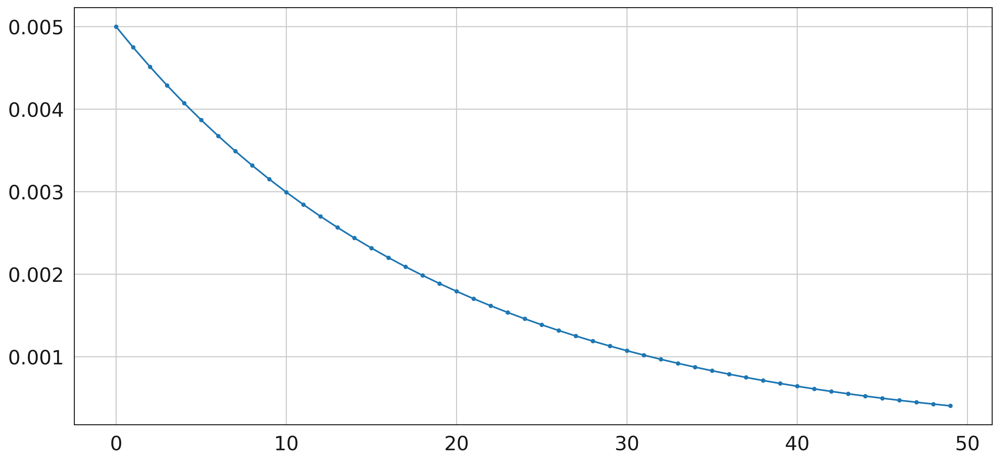

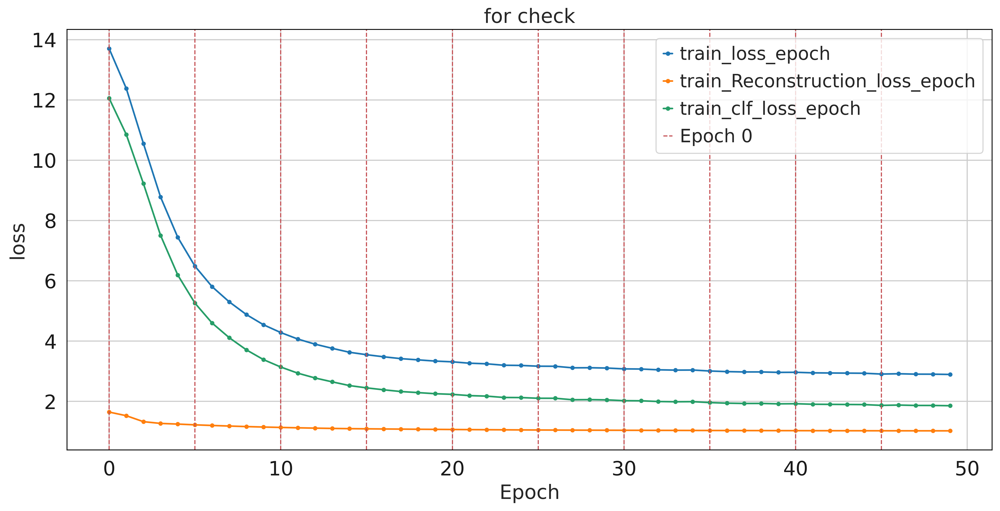

2026-03-16 02:57:58,361 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2026-03-16 02:57:58,361 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2026-03-16 02:57:58,361 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2026-03-16 02:57:58,361 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2026-03-16 02:57:58,377 INFO - tensorboard - No path found after /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_5/events.out.tfevents.1773647811.GPU2.2960570.5 
2026-03-16 02:57:58,377 INFO - tensorboard - No path found after /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_st

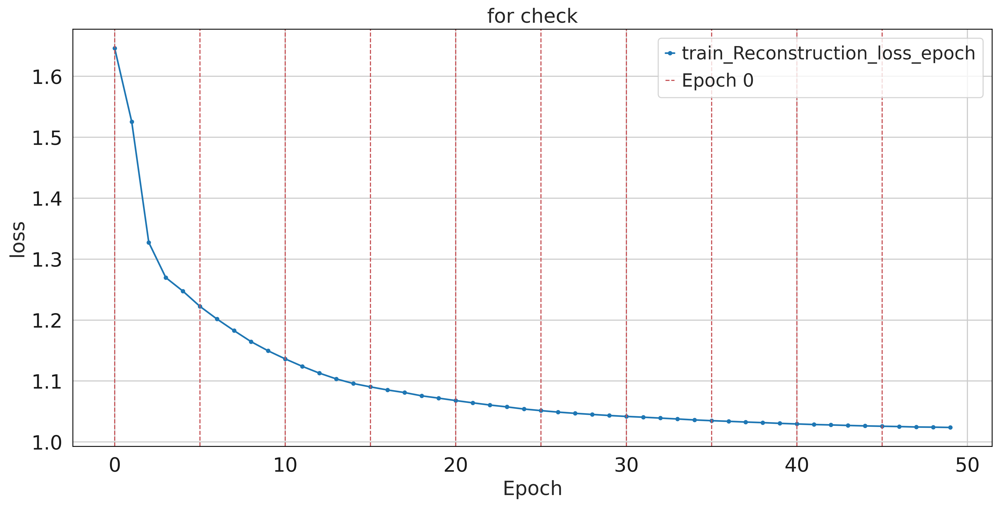

2026-03-16 02:57:59,376 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2026-03-16 02:57:59,376 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2026-03-16 02:57:59,376 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2026-03-16 02:57:59,376 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2026-03-16 02:57:59,392 INFO - tensorboard - No path found after /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_5/events.out.tfevents.1773647811.GPU2.2960570.5 
2026-03-16 02:57:59,392 INFO - tensorboard - No path found after /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_st

<Figure size 3000x1400 with 0 Axes>

In [140]:
sc_expression_train, y_time_nor_train, donor_index_train, runner, experiment, _m, train_clf_result, label_dic, total_result = onlyTrain_model(
        sc_expression_df_filter, donor_dic,
        "",
        cell_time_filter,
        time_standard_type, config, train_epoch_num,
        plot_latentSpaceUmap=False, plot_trainingLossLine=True, time_saved_asFloat=True, batch_dic=batch_dic, donor_str="dataset_label",
        batch_size=int(batch_size))

### Denormalize pseudotime to predicted time

In [141]:
predict_donors_df = pd.DataFrame(train_clf_result, columns=["pseudotime"], index=cell_time_filter.index)
predict_donors_df['predicted_time'] = predict_donors_df['pseudotime'].apply(denormalize, args=(min(label_dic.keys()) / 100, max(label_dic.keys()) / 100,
                                                                                               min(label_dic.values()), max(label_dic.values())))
cell_time_filter = pd.concat([cell_time_filter, predict_donors_df], axis=1)

In [142]:
cell_time_filter

,time,day,dataset_label,donor,cell_type,n_genes,pseudotime,predicted_time
CS7_315,17.5,D17.5_cui,C,D17.5_cui,Connecting stalk,216,3.501303,16.177020
CS7_317,17.5,D17.5_cui,C,D17.5_cui,Connecting stalk,238,3.439143,16.080671
CS7_318,17.5,D17.5_cui,C,D17.5_cui,Connecting stalk,219,3.499100,16.173605
CS7_320,17.5,D17.5_cui,C,D17.5_cui,Connecting stalk,227,3.586976,16.309812
CS7_324,17.5,D17.5_cui,C,D17.5_cui,Connecting stalk,199,3.436100,16.075955
...,...,...,...,...,...,...,...,...
E3.49.3407-p-b4,3.0,D3_p,P,D3_p,8 cell,551,-4.604569,3.612917
E3.51.3426-p-b4,3.0,D3_p,P,D3_p,8 cell,646,-4.608242,3.607225
E3.47.3391-p-b4,3.0,D3_p,P,D3_p,8 cell,526,-4.603695,3.614273
E3.52.3431-p-b4,3.0,D3_p,P,D3_p,8 cell,601,-4.609494,3.605285


latent mu save as /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//n50_latent_mu.h5ad


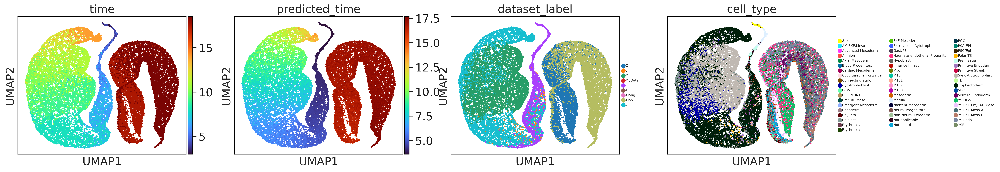

figure save as /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//n50_latentSpace_umap_byScanpy.png
Counter({'Z': 5911, 'C': 5082, 'Xiao': 4938, 'M': 4801, 'P': 1529, 'L': 989})


In [143]:
cell_time_filter = cell_time_filter.loc[:, ~cell_time_filter.columns.duplicated()]

adata_mu_reference = ad.AnnData(X=total_result["mu"].cpu().numpy())
adata_mu_reference.obs = cell_time_filter[["time", "predicted_time", "dataset_label", "cell_type", "day"]]

plt_umap_byScanpy(adata_mu_reference.copy(), ["time", "predicted_time", "dataset_label", "cell_type"], save_path=save_path, mode=None, figure_size=(5, 4),
                  color_map="turbo",
                  n_neighbors=50, n_pcs=20, special_file_name_str="n50_")  # color_map="viridis"
# add reference and query annotation
adata_mu_reference.obs['data_type'] = 'L & M & P & Z & Xiao & C'
print(f"{Counter(adata_mu_reference.obs['dataset_label'])}")

In [144]:
adata_mu_reference.obs

,time,predicted_time,dataset_label,cell_type,day,data_type
CS7_315,17.5,16.177020,C,Connecting stalk,D17.5_cui,L & M & P & Z & Xiao & C
CS7_317,17.5,16.080671,C,Connecting stalk,D17.5_cui,L & M & P & Z & Xiao & C
CS7_318,17.5,16.173605,C,Connecting stalk,D17.5_cui,L & M & P & Z & Xiao & C
CS7_320,17.5,16.309812,C,Connecting stalk,D17.5_cui,L & M & P & Z & Xiao & C
CS7_324,17.5,16.075955,C,Connecting stalk,D17.5_cui,L & M & P & Z & Xiao & C
...,...,...,...,...,...,...
E3.49.3407-p-b4,3.0,3.612917,P,8 cell,D3_p,L & M & P & Z & Xiao & C
E3.51.3426-p-b4,3.0,3.607225,P,8 cell,D3_p,L & M & P & Z & Xiao & C
E3.47.3391-p-b4,3.0,3.614273,P,8 cell,D3_p,L & M & P & Z & Xiao & C
E3.52.3431-p-b4,3.0,3.605285,P,8 cell,D3_p,L & M & P & Z & Xiao & C


## Use reference cell to generate a umap space.

### Use few cell to generate a umap space, random select cell from each time point and keep same cell number from each time point.

In [145]:
import umap
# less cell to train umap reducer.
umap_n_neighbors = 20
random_select_n_timePoint = 200
random_seed = 0
adata_subset = from_adata_randomSelect_cells_equityTimePoint(adata_mu_reference, random_select_n_timePoint=random_select_n_timePoint, random_seed=random_seed)
print(f"umap_n_neighbors: {umap_n_neighbors}, random_select_n_timePoint: {random_select_n_timePoint},random seed: {random_seed}")
umap_reducer = umap.UMAP(n_neighbors=umap_n_neighbors, min_dist=0.75, n_components=2, random_state=0)
adata_subset.obsm['X_umap'] = umap_reducer.fit_transform(adata_subset.X)
adata_mu_reference.obsm['X_umap'] = umap_reducer.transform(adata_mu_reference.X)

Before random select:
	Counter({'Z': 5911, 'C': 5082, 'Xiao': 4938, 'M': 4801, 'P': 1529, 'L': 989})
	 Counter({17.5: 5082, 18.5: 4938, 9.0: 3185, 8.0: 2077, 10.0: 1710, 11.0: 1616, 6.0: 1148, 12.0: 854, 14.0: 537, 6.5: 529, 7.0: 466, 5.0: 377, 7.5: 355, 4.0: 190, 5.5: 105, 3.0: 81})
	Counter({'Trophectoderm': 6333, 'Syncytiotrophoblast': 3559, 'YS.EXE.Meso-A': 1454, 'YS.DE/VE': 1398, 'YS.Endo': 1386, 'YS.EXE.Em/EXE.Meso': 1237, 'Haemato-endothelial Progenitor': 1149, 'Cytotrophoblast': 938, 'Epiblast': 932, 'YS.EXE.Meso-B': 784, 'Visceral Endoderm': 454, 'Amnion': 299, 'Erythroblast ': 290, 'Notochord': 281, 'MTE1': 275, 'Primitive Endoderm': 246, 'Endoderm': 232, 'Polar TE': 215, 'Connecting stalk': 194, 'Em/EXE.Meso': 182, 'Hypoblast': 179, 'Morula': 161, 'Primitive Streak': 151, 'MTE': 134, 'DE/VE': 127, 'Prelineage': 106, 'Not applicable': 96, 'Epi/Ecto': 71, 'MTE3': 71, 'Mesoderm': 64, '8 cell': 64, 'Inner cell mass': 44, 'Cocultured Ishikawa cell': 43, 'MTE2': 39, 'MIX': 39, 'EP

/mnt/yiming/nfs_share/anaconda3/envs/tvae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2026-03-16 03:00:28,730 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1] 
2026-03-16 03:00:28,730 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1] 
2026-03-16 03:00:28,730 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1] 
2026-03-16 03:00:28,730 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1] 
/mnt/yiming/nfs_share/anaconda3/envs/tvae/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:442: PossibleUserWarning: The dataloader, predict_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Predicting DataLoader 0: 100%|████████████████████| 1/1 [00:00<00:00,  2.78it/s]

2026-03-16 03:00:29,570 INFO - __main__ - predicted time of test donor is continuous. 
2026-03-16 03:00:29,570 INFO - __main__ - predicted time of test donor is continuous. 
2026-03-16 03:00:29,570 INFO - __main__ - predicted time of test donor is continuous. 
2026-03-16 03:00:29,570 INFO - __main__ - predicted time of test donor is continuous. 


2026-03-16 03:00:30,518 INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. 
2026-03-16 03:00:30,518 INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. 
2026-03-16 03:00:30,518 INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. 
2026-03-16 03:00:30,518 INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. 
/home/yiming/TemporalVAE

=== data correlation: 
Spearman correlation=0.46362, p-value=0.00000; 
Pearson correlation=0.55715, p-value=0.00000; 
Kendall correlation=0.36263, p-value=0.00000; 
R-squared=-0.39497.


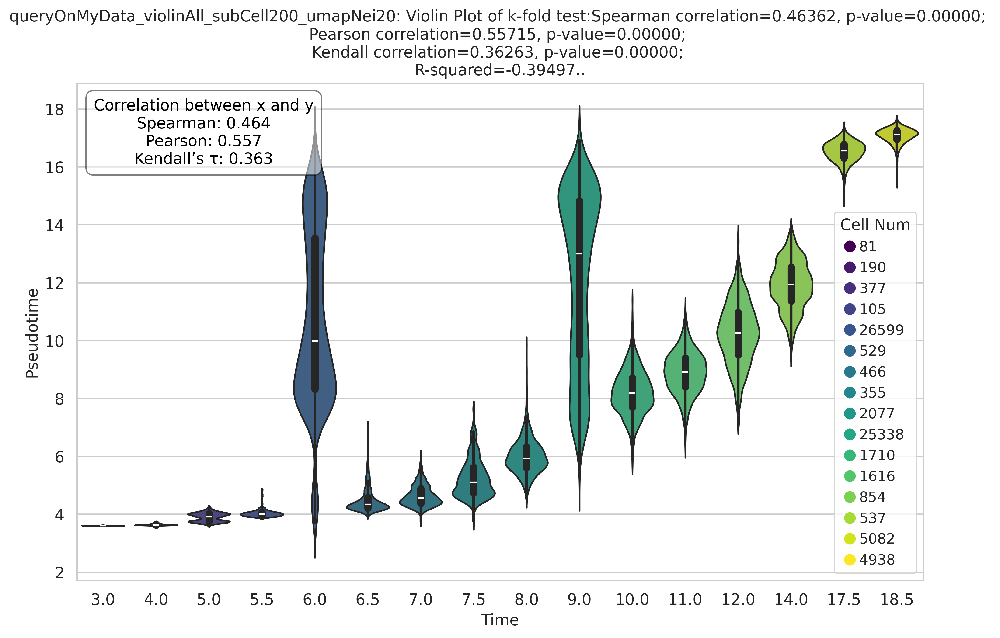

2026-03-16 03:00:32,617 INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. 
2026-03-16 03:00:32,617 INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. 
2026-03-16 03:00:32,617 INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. 
2026-03-16 03:00:32,617 INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. 


figure save as /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//queryOnMyData_violinAll_subCell200_umapNei20_violine.png
=== data correlation: 
Spearman correlation=0.33206, p-value=0.00000; 
Pearson correlation=0.33346, p-value=0.00000; 
Kendall correlation=0.27113, p-value=0.00000; 
R-squared=-2.46668.


/home/yiming/TemporalVAE/TemporalVAE/utils/utils_plot.py:1566: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=x_attr, y=y_attr, data=boxPlot_df, palette=color_map, bw=0.2, scale='width')
/home/yiming/TemporalVAE/TemporalVAE/utils/utils_plot.py:1566: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x=x_attr, y=y_attr, data=boxPlot_df, palette=color_map, bw=0.2, scale='width')
/home/yiming/TemporalVAE/TemporalVAE/utils/utils_plot.py:1566: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(x=x_attr, y=y_attr, data=boxPlot_df, palette=color_map, bw

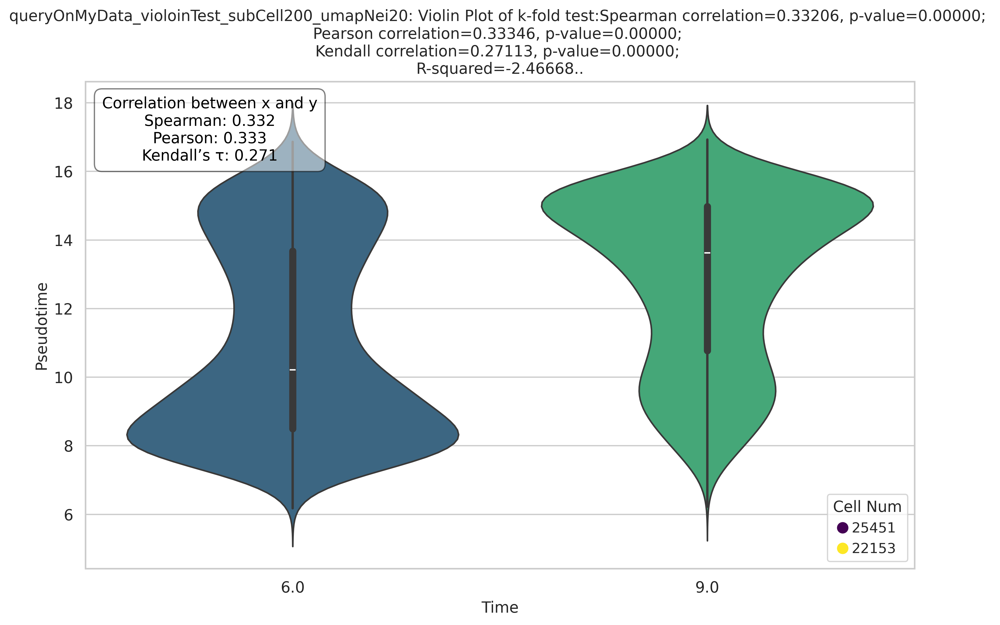

2026-03-16 03:00:34,129 INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. 
2026-03-16 03:00:34,129 INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. 
2026-03-16 03:00:34,129 INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. 
2026-03-16 03:00:34,129 INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. 
/home/yiming/TemporalVAE

figure save as /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//queryOnMyData_violoinTest_subCell200_umapNei20_violine.png
=== data correlation: 
Spearman correlation=0.96846, p-value=0.00000; 
Pearson correlation=0.99176, p-value=0.00000; 
Kendall correlation=0.88099, p-value=0.00000; 
R-squared=0.89018.


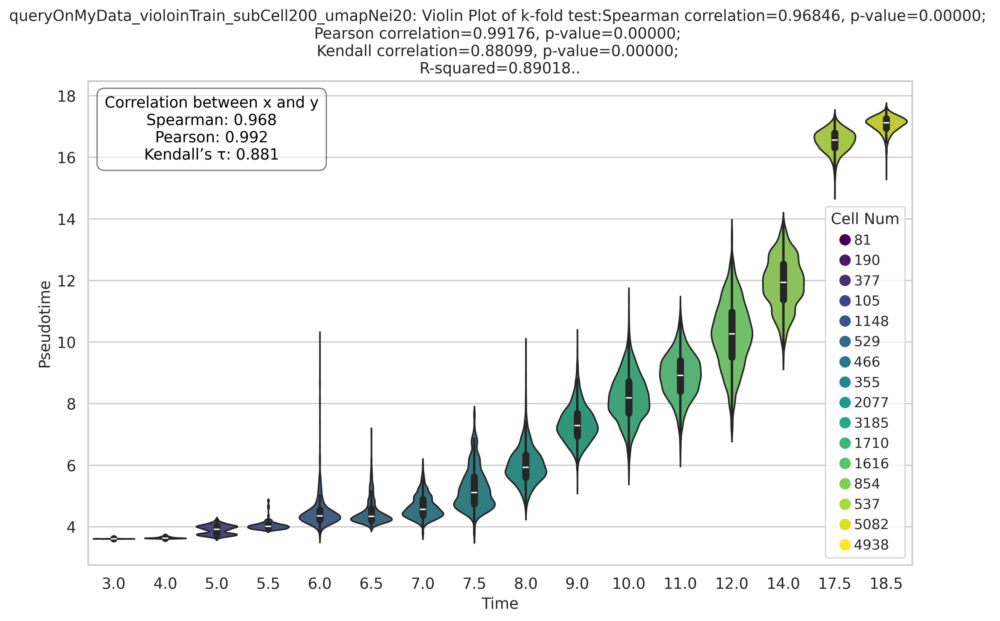

figure save as /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//queryOnMyData_violoinTrain_subCell200_umapNei20_violine.png
Counter({'Z': 5911, 'C': 5082, 'Xiao': 4938, 'M': 4801, 'P': 1529, 'L': 989})
Counter({17.5: 5082, 18.5: 4938, 9.0: 3185, 8.0: 2077, 10.0: 1710, 11.0: 1616, 6.0: 1148, 12.0: 854, 14.0: 537, 6.5: 529, 7.0: 466, 5.0: 377, 7.5: 355, 4.0: 190, 5.5: 105, 3.0: 81})


... storing 'data_type' as categorical
... storing 'cell_typeMask4dataset' as categorical
... storing 'cell_typeMaskTyser' as categorical
/home/yiming/TemporalVAE/TemporalVAE/utils/utils_plot.py:2067: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_all.obs[attr] = adata_all.obs[attr].replace('Haemato-endothelial Progenitor',
/home/yiming/TemporalVAE/TemporalVAE/utils/utils_plot.py:2075: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_all.obs[attr] = adata_all.obs[attr].replace(other_categories, "Other cell type")


Final plot dataset information: Counter({'MyData': 47604, 'Z': 5911, 'C': 5082, 'Xiao': 4938, 'M': 4801, 'P': 1529, 'L': 989})
more than 15 cell type, so trans cell type with less cells to Other cell type in image.


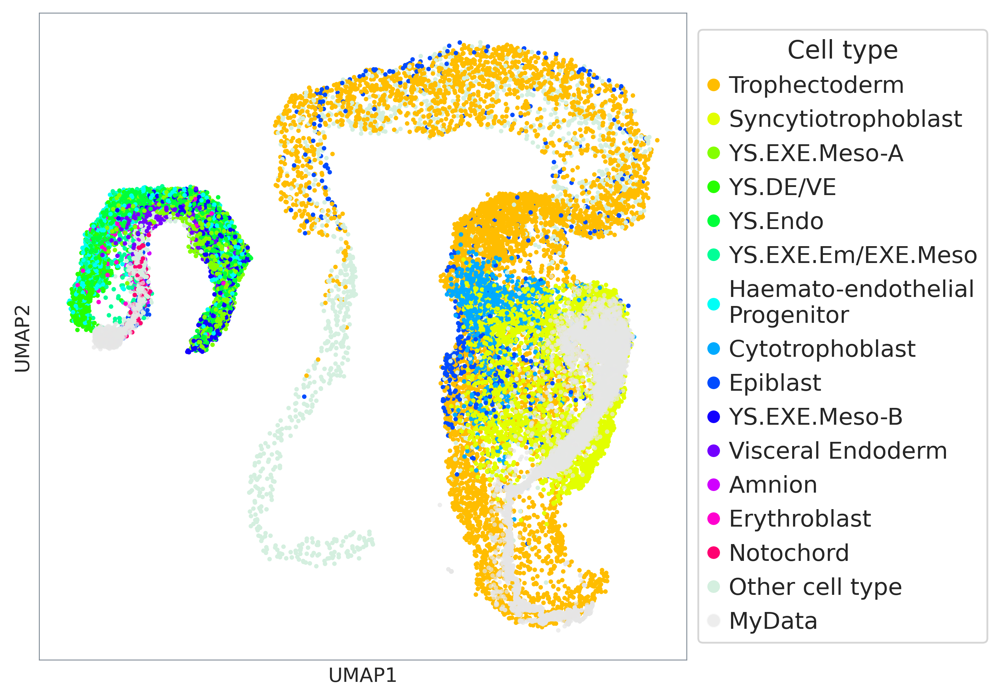

figure save at /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//tyser_mapping_to_C&Xiao&L&Z&M&P&MyData_cell_typeMaskTyser_maskMyData_queryMyData_subCell200_umapNei20.png


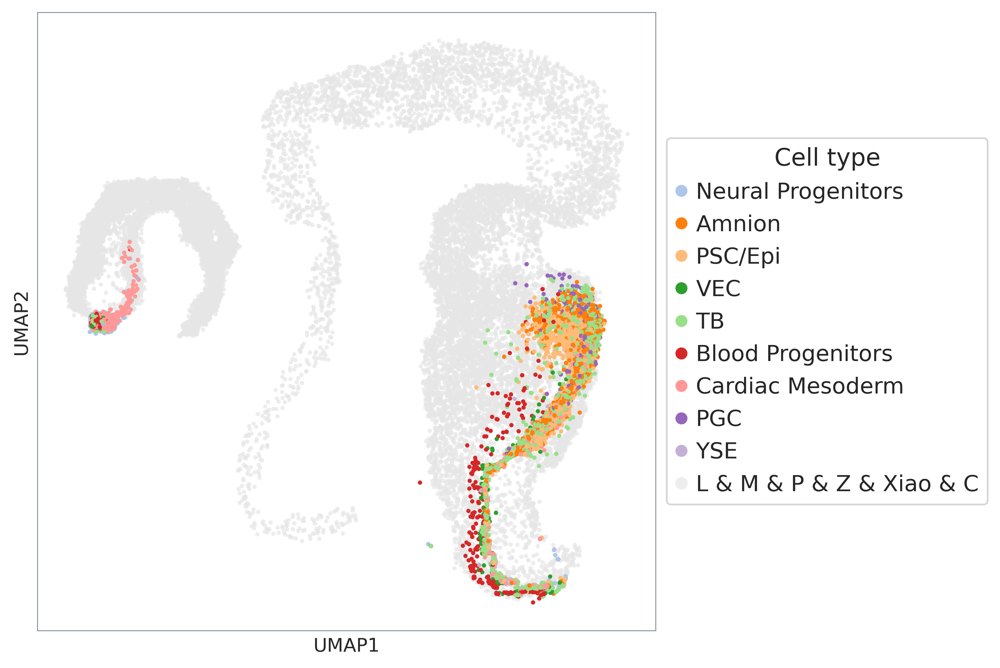

... storing 'plot_color' as categorical


figure save at /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//tyser_mapping_to_C&Xiao&L&Z&M&P&MyData_cell_typeMask4dataset_maskL&M&P&Z&Xiao&C_queryMyData_subCell200_umapNei20.png


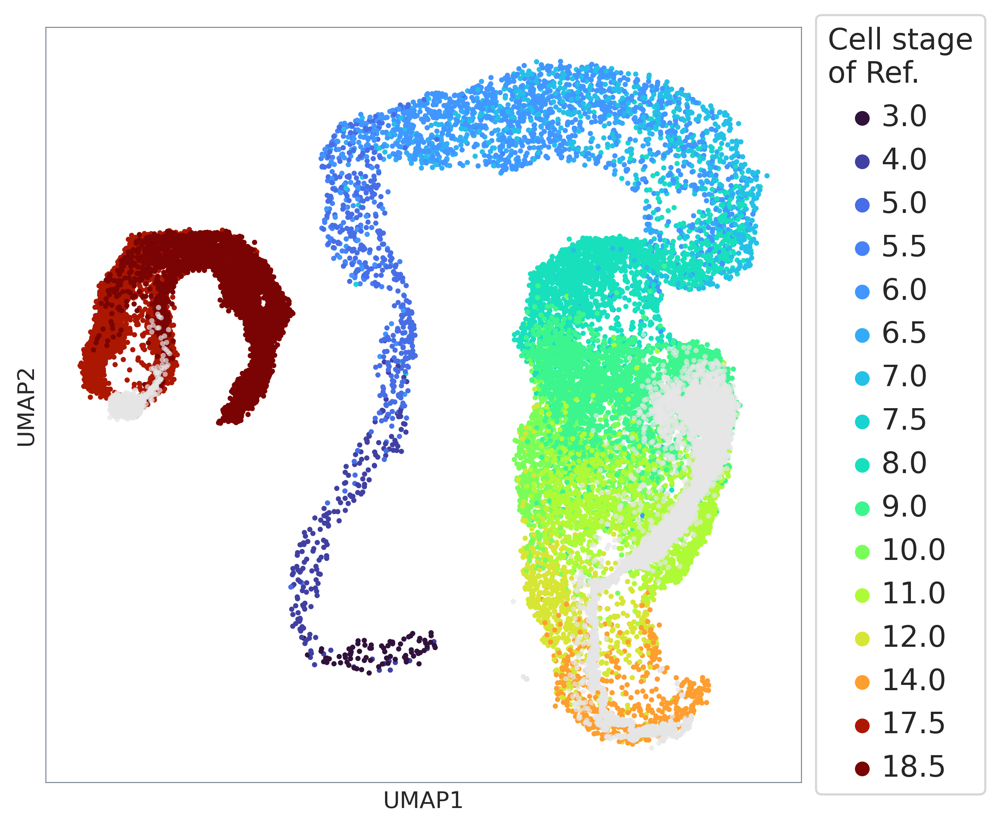

... storing 'plot_color' as categorical


figure save at /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//tyser_mapping_to_C&Xiao&L&Z&M&P&MyData_time_cellStageOnDataset_maskMyData_queryMyData_subCell200_umapNei20.png


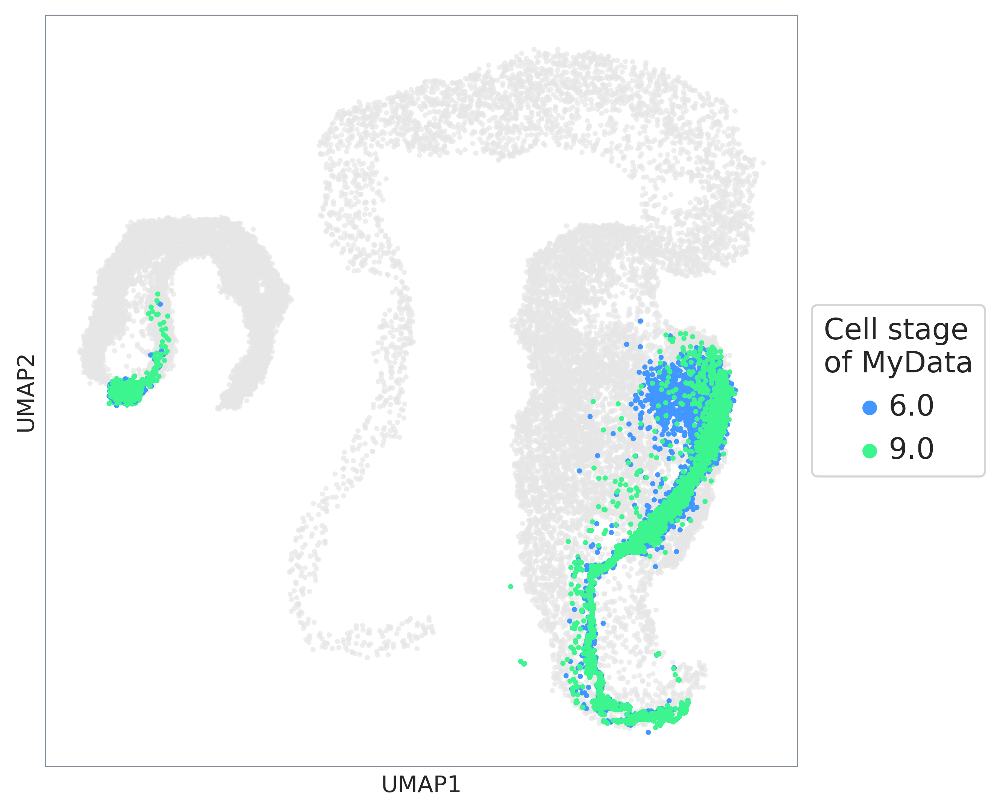

figure save at /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//tyser_mapping_to_C&Xiao&L&Z&M&P&MyData_time_cellStageOnDataset_maskL&M&P&Z&Xiao&C_queryMyData_subCell200_umapNei20.png


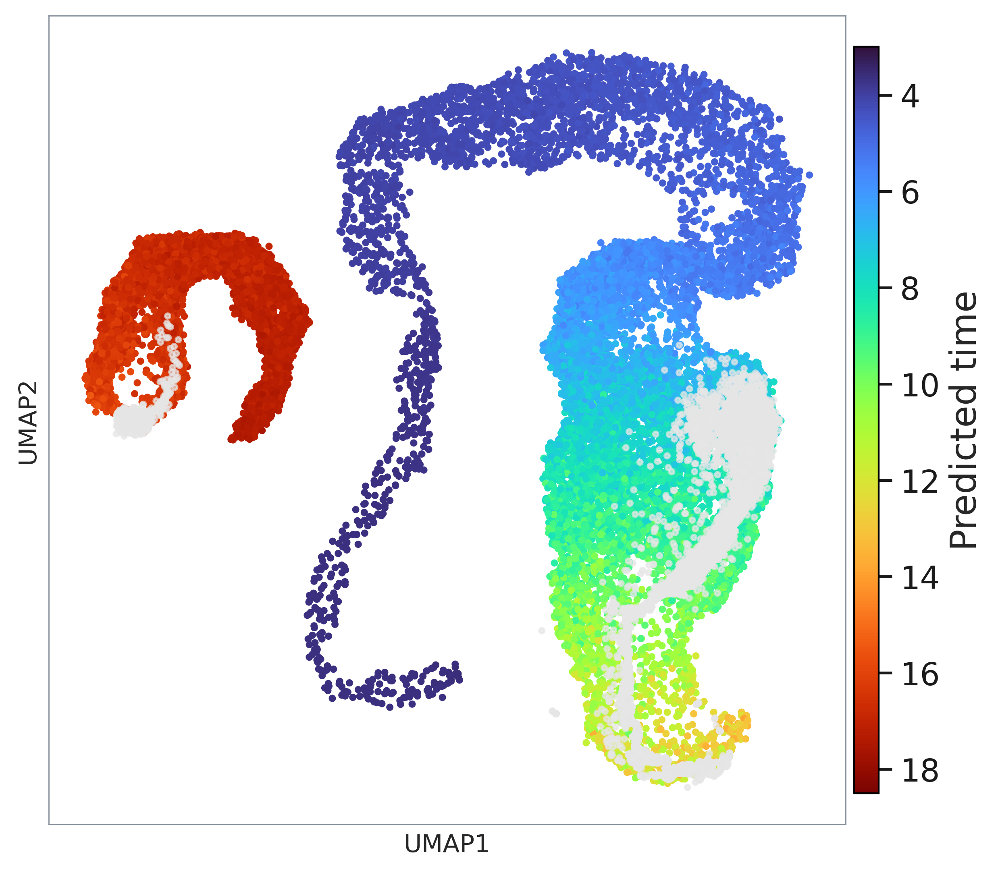

figure save at /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//tyser_mapping_to_C&Xiao&L&Z&M&P&MyData_predicted_time_maskMyData_queryMyData_subCell200_umapNei20.png


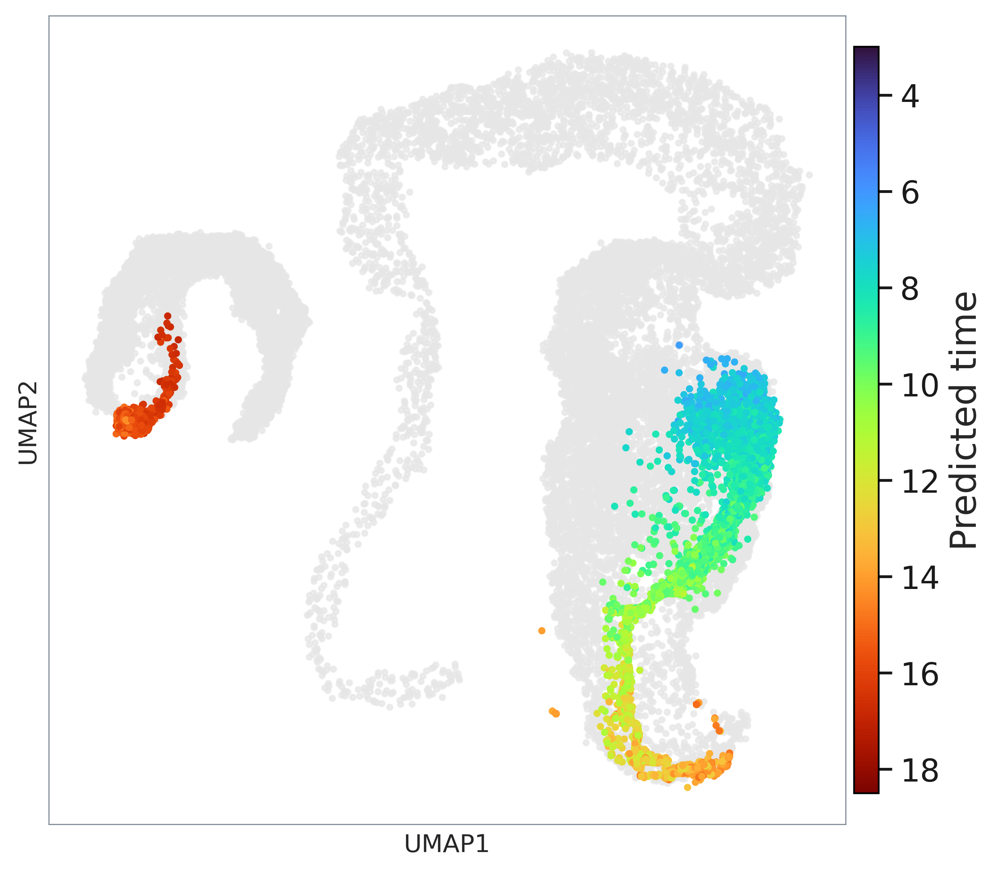

figure save at /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//tyser_mapping_to_C&Xiao&L&Z&M&P&MyData_predicted_time_maskL&M&P&Z&Xiao&C_queryMyData_subCell200_umapNei20.png


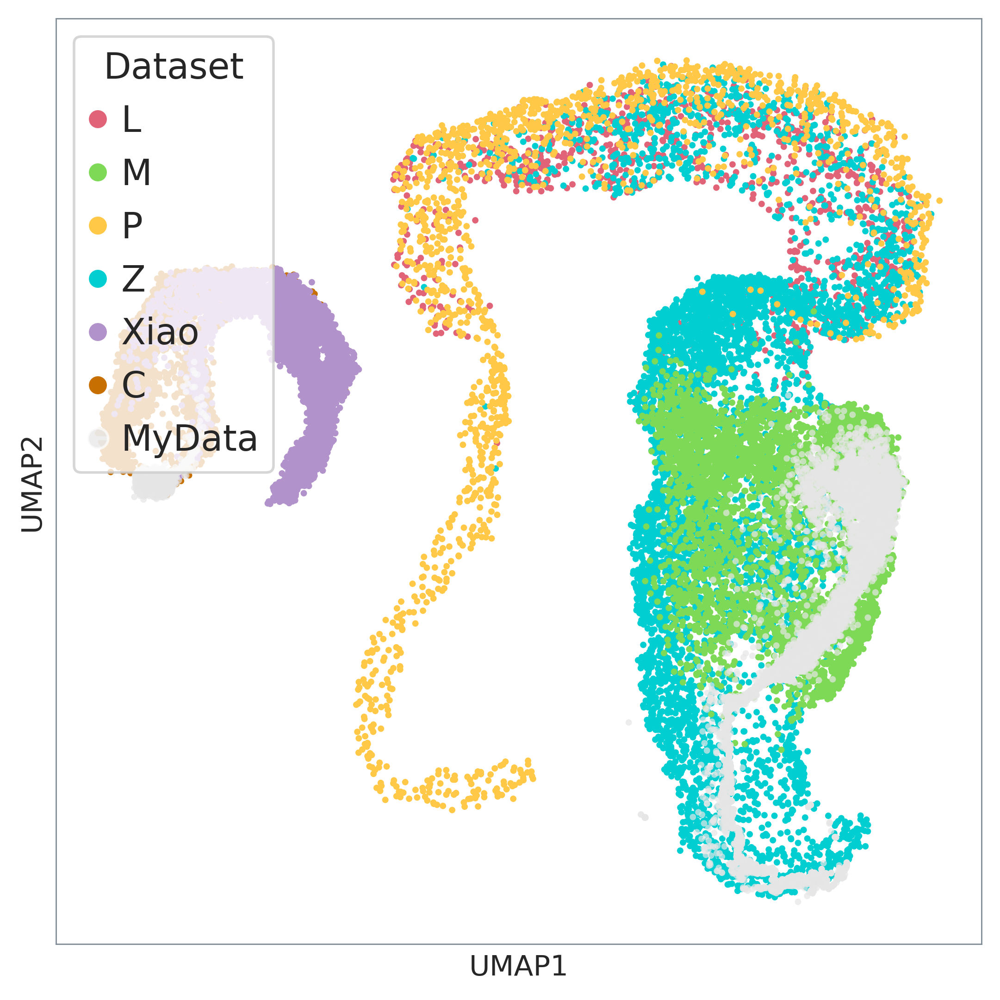

figure save at /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//tyser_mapping_to_C&Xiao&L&Z&M&P&MyData_dataset_label_maskMyData_queryMyData_subCell200_umapNei20.png


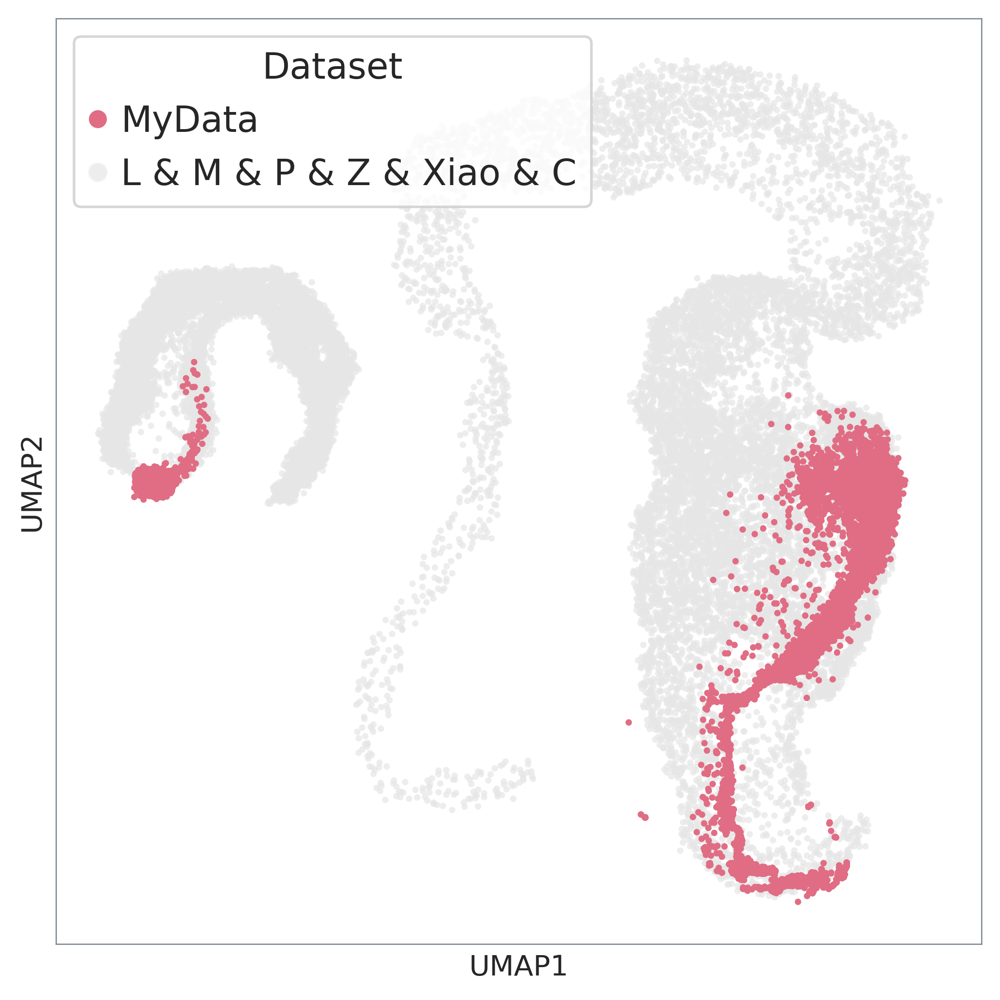

figure save at /home/yiming/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnDavid/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//tyser_mapping_to_C&Xiao&L&Z&M&P&MyData_data_type_maskL&M&P&Z&Xiao&C_queryMyData_subCell200_umapNei20.png


In [146]:
adata_mu_query_David=queryOneDataset_referenceOn6Datasets_humanEmbryo("MyData",
                                                     cell_time, sc_expression_df,
                                                     time_standard_type, label_dic, batch_dic,
                                                     runner, experiment, adata_mu_reference.copy(), _logger, save_path,
                                                     umap_reducer,
                                                     special_file_name=f"_subCell{random_select_n_timePoint}_umapNei{umap_n_neighbors}"
                                                     )

### Save results

In [34]:
_adata_temp = anndata.concat([adata_mu_reference.copy(), adata_mu_query_T.copy(),adata_mu_query_Xiang], axis=0)
adata_filtered.obsm["X_umap"] = _adata_temp[adata_filtered.obs.index].obsm["X_umap"]
adata_filtered.obsm['tvae_emb'] = _adata_temp[adata_filtered.obs.index].X
adata_filtered.obs['tvae_predicted_time'] = _adata_temp[adata_filtered.obs.index].obs["predicted_time"]  # for reconstruction or prediction (optional)
adata_filtered.write_h5ad(f"{save_path}/rawCount_Z_C_Xiao_M_P_Liu_Tyser_Xiang.filtered.h5ad")
print(f"Save raw count, processed data, umap, low-dim embedding and prediction at {save_path}/rawCount_Z_C_Xiao_M_P_Liu_Tyser_Xiang.filtered.h5ad")

Save raw count, processed data, umap, low-dim embedding and prediction at /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/test/TemporalVAE_human_ref6dataset_queryOnXiang/human_embryo_preimplantation/integration_8dataset/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch50_minGeneNum50//rawCount_Z_C_Xiao_M_P_Liu_Tyser_Xiang.filtered.h5ad


## Use all cell to train umap reducer

#Sup. Fig 3 A.

In [ ]:
umap_n_neighbors = 50
umap_reducer = umap.UMAP(n_neighbors=umap_n_neighbors, min_dist=0.75, n_components=2, random_state=0)
print(f"{Counter(adata_mu_reference.obs['dataset_label'])}")
print(f"{Counter(adata_mu_reference.obs['time'])}")
adata_mu_reference.obsm['X_umap'] = umap_reducer.fit_transform(adata_mu_reference.X)
adata_mu_reference.obsm['X_umap'] = umap_reducer.transform(adata_mu_reference.X)

adata_mu_query_David_all=queryOneDataset_referenceOn6Datasets_humanEmbryo("MyData",
cell_time, sc_expression_df,
time_standard_type, label_dic, batch_dic,
runner, experiment, adata_mu_reference.copy(), _logger, save_path,
umap_reducer,
special_file_name=f"_umapNei{umap_n_neighbors}"
)

In [149]:
adata_mu_query_David_all.obs

,time,predicted_time,dataset_label,day,cell_type,data_type
AAACCAAAGGCGTACT-1-WT_d6,6.0,13.732079,MyData,WT_d6,Neural Progenitors,MyData
AAACCAAAGTACGGCT-1-WT_d6,6.0,8.318786,MyData,WT_d6,Amnion,MyData
AAACCAAAGTATGTCG-1-WT_d6,6.0,14.142658,MyData,WT_d6,Neural Progenitors,MyData
AAACCAAAGTCGCATA-1-WT_d6,6.0,12.874243,MyData,WT_d6,Neural Progenitors,MyData
AAACCAAAGTTGGATT-1-WT_d6,6.0,14.419479,MyData,WT_d6,Neural Progenitors,MyData
...,...,...,...,...,...,...
TGTGTACGTTGGGCCT-1-KO_d9,9.0,7.222080,MyData,KO_d9,Amnion,MyData
TGTGTACGTTGTCTGG-1-KO_d9,9.0,14.647938,MyData,KO_d9,TB,MyData
TGTGTACGTTGTGGTT-1-KO_d9,9.0,12.356524,MyData,KO_d9,TB,MyData
TGTGTTAGTTCCCAGA-1-KO_d9,9.0,10.873424,MyData,KO_d9,Cardiac Mesoderm,MyData


In [152]:
adata = adata_mu_query_David_all

adata.obs["condition"] = adata.obs["day"].str.split("_").str[0]
adata.obs["stage"] = adata.obs["day"].str.split("_").str[1]

#Sup Fig. 3 B.

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

d9_KO vs. d9_WT: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=2.592e+07
d6_KO vs. d6_WT: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=2.282e+07


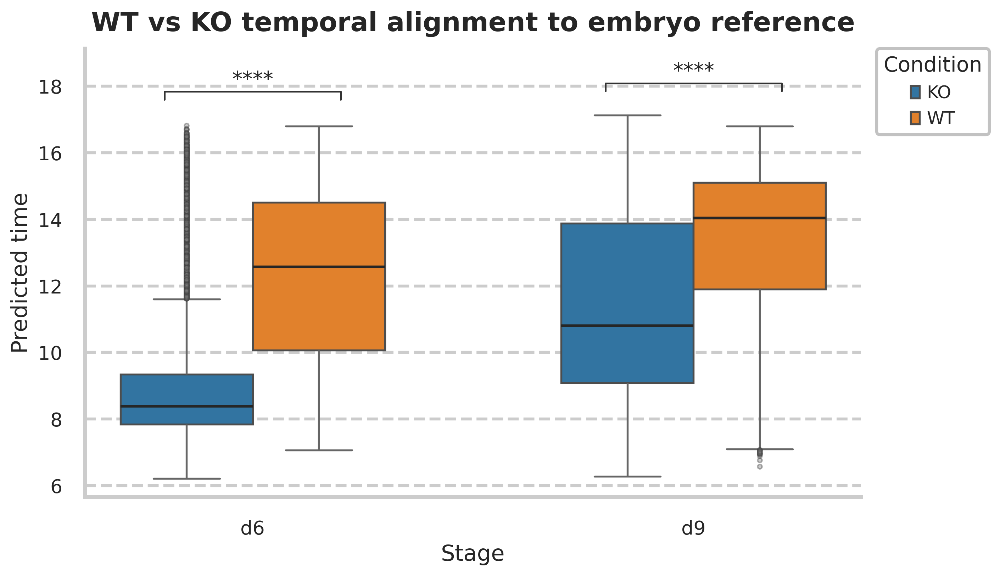

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from statannotations.Annotator import Annotator
from itertools import combinations


sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.3})
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "figure.dpi": 150,
})


df = adata.obs.copy()
stages = sorted(df["stage"].unique())
conditions = sorted(df["condition"].unique())


pairs = []
for stg in stages:
    for c1, c2 in combinations(conditions, 2):
        grp1 = df[(df["stage"] == stg) & (df["condition"] == c1)]
        grp2 = df[(df["stage"] == stg) & (df["condition"] == c2)]
        if len(grp1) >= 2 and len(grp2) >= 2:
            pairs.append(((stg, c1), (stg, c2)))


fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="stage",
    y="predicted_time",
    hue="condition",
    order=stages,
    hue_order=conditions,
    width=0.6,
    linewidth=1.3,
    fliersize=3,
    flierprops=dict(marker="o", markerfacecolor="grey", alpha=0.4),
    boxprops=dict(edgecolor="0.3"),
    medianprops=dict(color="0.15", linewidth=1.8),
    whiskerprops=dict(color="0.4"),
    capprops=dict(color="0.4"),
    ax=ax,
)


if pairs:
    annotator = Annotator(
        ax,
        pairs=pairs,
        data=df,
        x="stage",
        y="predicted_time",
        hue="condition",
        order=stages,
        hue_order=conditions,
    )
    annotator.configure(
        test="Mann-Whitney",         
        text_format="star",        
        loc="inside",
        fontsize=14,
        line_height=0.02,
        line_width=1.2,
        comparisons_correction=None,  
    )
    annotator.apply_and_annotate()


ax.set_title(
    "WT vs KO temporal alignment to embryo reference",
    fontsize=18, fontweight="bold", pad=12,
)
ax.set_xlabel("Stage", fontsize=15)
ax.set_ylabel("Predicted time", fontsize=15)
ax.tick_params(axis="x", labelsize=13, rotation=0)
ax.tick_params(axis="y", labelsize=13)


ax.legend(
    title="Condition",
    title_fontsize=14,
    fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=True,
    edgecolor="0.7",
)

sns.despine(ax=ax, left=False, bottom=False)


plt.tight_layout()
fig.savefig("boxplot_WT_vs_KO.pdf", bbox_inches="tight", facecolor="white")
fig.savefig("boxplot_WT_vs_KO.png", bbox_inches="tight", facecolor="white", dpi=300)
plt.show()

In [156]:
for stage in ["d6","d9"]:
    for ct in adata.obs.cell_type.unique():
        subset = adata.obs[
            (adata.obs.stage==stage) &
            (adata.obs.cell_type==ct)
        ]
        if subset.condition.nunique()==2:
            wt = subset[subset.condition=="WT"]["predicted_time"]
            ko = subset[subset.condition=="KO"]["predicted_time"]
            print(stage, ct, mannwhitneyu(wt,ko).pvalue)

d6 Neural Progenitors 5.278745552337573e-06
d6 Amnion 1.5231093164741737e-96
d6 PSC/Epi 0.0
d6 VEC 0.007134901965809123
d6 TB 8.005887549970515e-10
d6 Blood Progenitors 9.591397996154456e-06
d6 Cardiac Mesoderm 2.599378634375181e-09
d6 PGC 0.21280877722595512
d6 YSE 0.8627774720990002
d9 Neural Progenitors 0.002446085175908967
d9 Amnion 6.867834698730539e-08
d9 PSC/Epi 1.038602411638349e-15
d9 VEC 0.26059527565548257
d9 TB 0.10914204054757384
d9 Blood Progenitors 0.40032104270403734
d9 Cardiac Mesoderm 0.7623780752580236
d9 PGC 0.013197914149641835
d9 YSE 0.21686746987951805


#Sup Fig 3 C.

/tmp/ipykernel_2960570/3728919230.py:55: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

d9_WT vs. d9_KO: Mann-Whitney-Wilcoxon test two-sided, P_val:2.446e-03 U_stat=4.983e+04
d6_WT vs. d6_KO: Mann-Whitney-Wilcoxon test two-sided, P_val:5.279e-06 U_stat=6.705e+04


/tmp/ipykernel_2960570/3728919230.py:55: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

d9_WT vs. d9_KO: Mann-Whitney-Wilcoxon test two-sided, P_val:6.868e-08 U_stat=5.464e+04
d6_WT vs. d6_KO: Mann-Whitney-Wilcoxon test two-sided, P_val:1.523e-96 U_stat=8.231e+05


/tmp/ipykernel_2960570/3728919230.py:55: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.boxplot(


...

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

d9_WT vs. d9_KO: Mann-Whitney-Wilcoxon test two-sided, P_val:7.624e-01 U_stat=1.693e+04
d6_WT vs. d6_KO: Mann-Whitney-Wilcoxon test two-sided, P_val:2.599e-09 U_stat=4.688e+04


/tmp/ipykernel_2960570/3728919230.py:55: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

d9_WT vs. d9_KO: Mann-Whitney-Wilcoxon test two-sided, P_val:1.320e-02 U_stat=6.300e+01
d6_WT vs. d6_KO: Mann-Whitney-Wilcoxon test two-sided, P_val:2.128e-01 U_stat=3.440e+02


/tmp/ipykernel_2960570/3728919230.py:55: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

d6_WT vs. d6_KO: Mann-Whitney-Wilcoxon test two-sided, P_val:8.628e-01 U_stat=4.290e+02


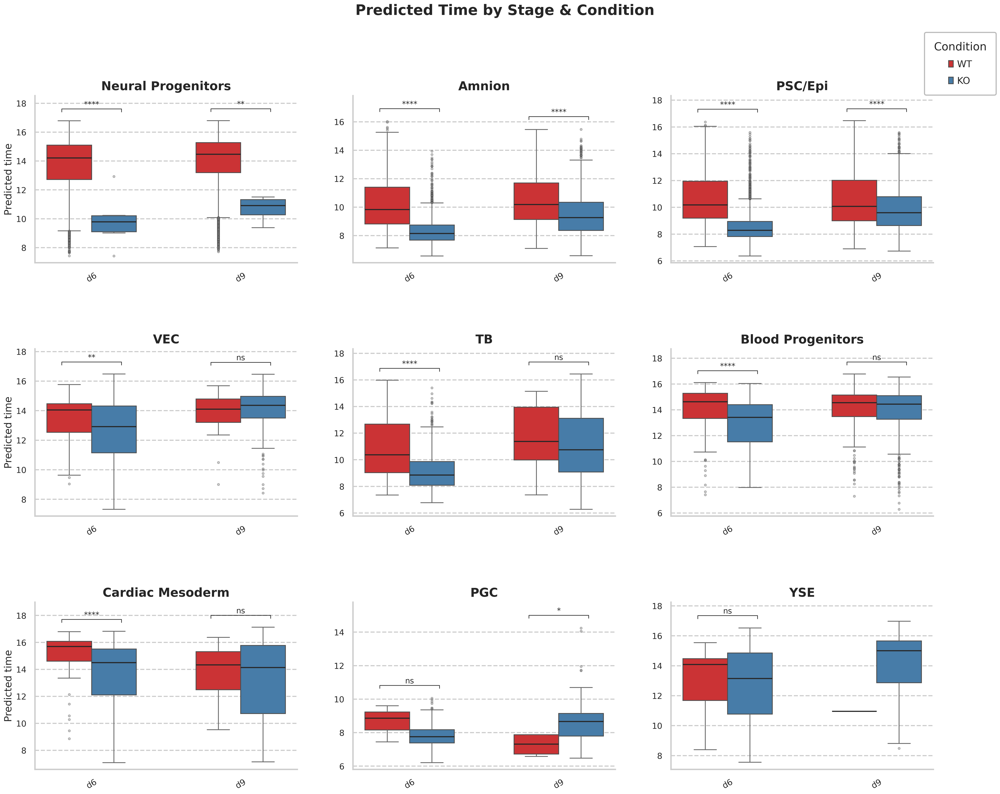

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl
from statannotations.Annotator import Annotator   # pip install statannotations


sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.3})
sns.set_context("poster", font_scale=1.1)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.titleweight": "bold",
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "figure.dpi": 150,
})


PALETTE = sns.color_palette("Set1")


adata = adata_mu_query_David_all
cell_types = adata.obs["cell_type"].unique()

n_rows, n_cols = 3, 3
max_plots = n_rows * n_cols

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(26, 20),
    constrained_layout=False,
)
axes = axes.flatten()


conditions = sorted(adata.obs["condition"].unique())
stages = sorted(adata.obs["stage"].unique())


from itertools import combinations
pairs = []
for stg in stages:
    for c1, c2 in combinations(conditions, 2):
        pairs.append(((stg, c1), (stg, c2)))


for i, ct in enumerate(cell_types[:max_plots]):
    subset = adata.obs[adata.obs["cell_type"] == ct].copy()
    ax = axes[i]


    sns.boxplot(
        data=subset,
        x="stage",
        y="predicted_time",
        hue="condition",
        palette=PALETTE,
        width=0.6,
        linewidth=1.5,
        fliersize=4,
        flierprops=dict(marker="o", markerfacecolor="grey", alpha=0.4),
        boxprops=dict(edgecolor="0.3"),
        medianprops=dict(color="0.15", linewidth=2.0),
        whiskerprops=dict(color="0.4"),
        capprops=dict(color="0.4"),
        ax=ax,
    )


    valid_pairs = []
    for (s1, c1), (s2, c2) in pairs:
        grp1 = subset[(subset["stage"] == s1) & (subset["condition"] == c1)]
        grp2 = subset[(subset["stage"] == s2) & (subset["condition"] == c2)]
        if len(grp1) >= 2 and len(grp2) >= 2:      # 至少 2 个样本才能检验
            valid_pairs.append(((s1, c1), (s2, c2)))


    if valid_pairs:
        annotator = Annotator(
            ax,
            pairs=valid_pairs,
            data=subset,
            x="stage",
            y="predicted_time",
            hue="condition",
            # order=stages,              
            # hue_order=conditions,
        )
        annotator.configure(
            test="Mann-Whitney",          
            text_format="star",          
            loc="inside",
            fontsize=14,
            line_height=0.02,
            line_width=1.2,
            comparisons_correction=None,   
        )
        annotator.apply_and_annotate()


    ax.set_title(ct, fontsize=22, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Predicted time" if i % n_cols == 0 else "", fontsize=18)
    ax.tick_params(axis="x", rotation=30, labelsize=15)
    ax.tick_params(axis="y", labelsize=15)

    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

    sns.despine(ax=ax, left=False, bottom=False)


for j in range(i + 1, max_plots):
    fig.delaxes(axes[j])


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    title="Condition",
    title_fontsize=20,
    fontsize=17,
    frameon=True,
    fancybox=True,
    shadow=False,
    edgecolor="0.7",
    facecolor="white",
    framealpha=0.9,
    borderpad=1.0,
    labelspacing=0.8,
)


fig.suptitle(
    "Predicted Time by Stage & Condition",
    fontsize=26,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout(rect=[0, 0, 0.93, 0.97], h_pad=3.5, w_pad=2.5)
plt.savefig("boxplot_grid_stat.pdf", bbox_inches="tight", facecolor="white")
plt.show()